Using degree 401

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [2]:
def mod_reduction(bit_position):
    period = 2**bit_position
    
    assert period % 2 == 0 and period >= 2
    P = period
    seq = np.array([0]*(P//2) + [1]*(P//2), dtype=float)

    c = np.fft.fft(seq) / P

    def f(x):
        s = c[0].real
        for k in range(1, P//2):
            ck = c[k]
            ang = 2 * math.pi * k * x / P
            s += 2 * (ck.real * math.cos(ang) - ck.imag * math.sin(ang))

        s += c[P//2].real * math.cos(math.pi * x)
        return s
    
    return f

In [5]:
a=0
b=256

p1 = Chebyshev(a, b, 451, mod_reduction(1))           # Period 2 {0, 1}
p2 = Chebyshev(a, b, 401, mod_reduction(2))           # Period 4 {0, 0, 1, 1}
p3 = Chebyshev(a, b, 401, mod_reduction(3))           # Period 8 {0, 0, 0, 0, 1, 1, 1, 1}
p4 = Chebyshev(a, b, 401, mod_reduction(4))           # Period 16 
p5 = Chebyshev(a, b, 401, mod_reduction(5))           # Period 32
p6 = Chebyshev(a, b, 401, mod_reduction(6))           # Period 64
p7 = Chebyshev(a, b, 401, mod_reduction(7))           # Period 128
p8 = Chebyshev(a, b, 401, mod_reduction(8))           # Period 256

Error for p1: 4.193558778009532e-09


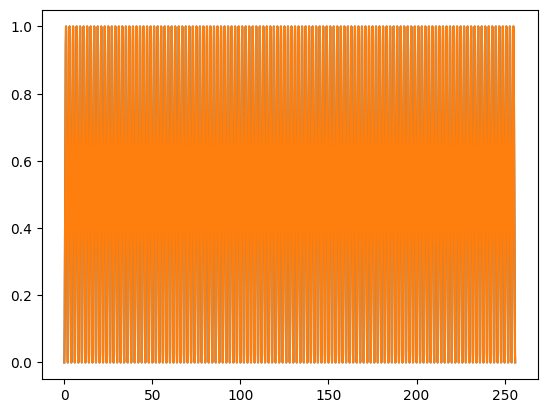

In [6]:
x = np.arange(a, b, 0.01)

plt.plot(x, np.vectorize(mod_reduction(1))(x))
plt.plot(x, np.vectorize(p1.eval)(x))

print("Error for p1: {}".format(max(abs(np.vectorize(mod_reduction(1))(x) - np.vectorize(p1.eval)(x)))))

Error for p2: 1.0025313912365164e-13


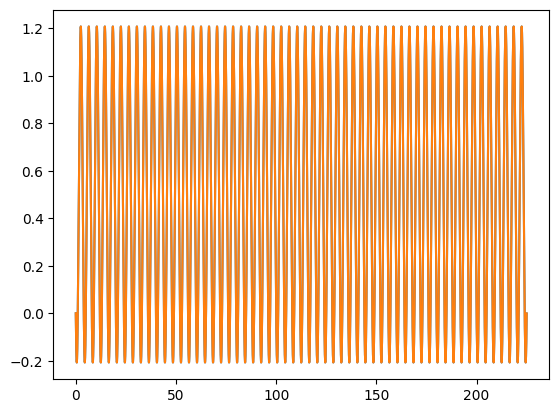

In [5]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(2))(x))
plt.plot(x, np.vectorize(p2.eval)(x))

print("Error for p2: {}".format(max(abs(np.vectorize(mod_reduction(2))(x) - np.vectorize(p2.eval)(x)))))

Error for p1: 7.793765632868599e-14


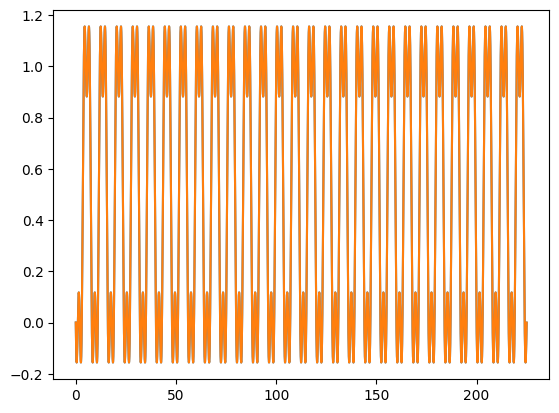

In [6]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(3))(x))
plt.plot(x, np.vectorize(p3.eval)(x))

print("Error for p1: {}".format(max(abs(np.vectorize(mod_reduction(3))(x) - np.vectorize(p3.eval)(x)))))

Error for p4: 7.838174553853605e-14


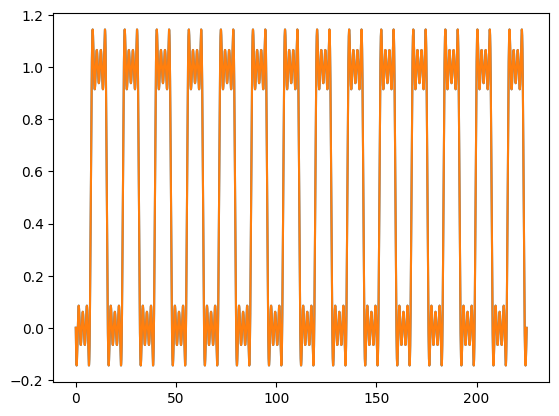

In [7]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(4))(x))
plt.plot(x, np.vectorize(p4.eval)(x))

print("Error for p4: {}".format(max(abs(np.vectorize(mod_reduction(4))(x) - np.vectorize(p4.eval)(x)))))

Error for p5: 6.94999613415348e-14


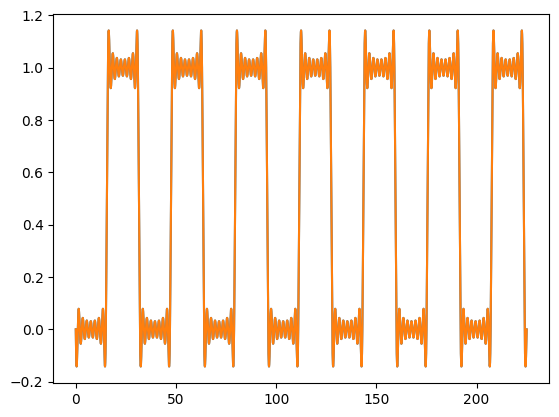

In [8]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(5))(x))
plt.plot(x, np.vectorize(p5.eval)(x))

print("Error for p5: {}".format(max(abs(np.vectorize(mod_reduction(5))(x) - np.vectorize(p5.eval)(x)))))

Error for p6: 2.9176661087149114e-13


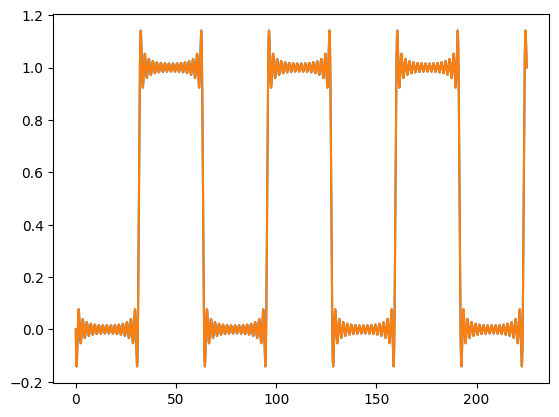

In [12]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(6))(x))
plt.plot(x, np.vectorize(p6.eval)(x))

print("Error for p6: {}".format(max(abs(np.vectorize(mod_reduction(6))(x) - np.vectorize(p6.eval)(x)))))

Error for p7: 3.1011217899168386e-12


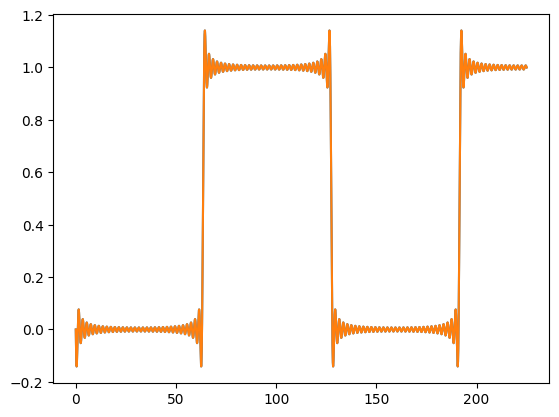

In [10]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(7))(x))
plt.plot(x, np.vectorize(p7.eval)(x))

print("Error for p7: {}".format(max(abs(np.vectorize(mod_reduction(7))(x) - np.vectorize(p7.eval)(x)))))

Error for p8: 6.596723167717755e-12


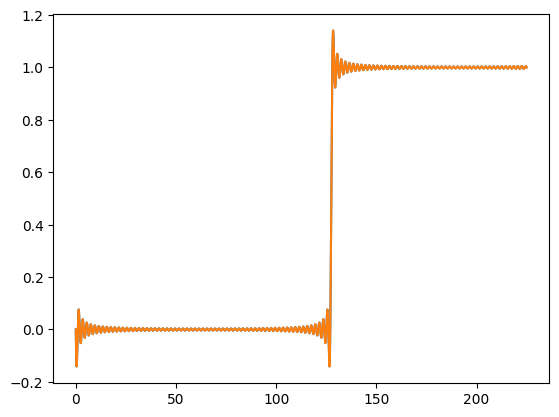

In [11]:
x = np.arange(a, b, 0.001)

plt.plot(x, np.vectorize(mod_reduction(8))(x))
plt.plot(x, np.vectorize(p8.eval)(x))

print("Error for p8: {}".format(max(abs(np.vectorize(mod_reduction(8))(x) - np.vectorize(p8.eval)(x)))))